# Imports


In [42]:
import sys
sys.path.insert(0, "..")

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, fbeta_score
from scripts.preprocess_neo import preprocess_neo
from scripts.utils import load_and_split_neo_data

In [44]:
df_raw = pd.read_csv("../data/neo_v2.csv")
df_clean = preprocess_neo(df_raw)
df_clean.to_csv("../data/neo_preprocessed.csv", index=False)

train_df, test_df = load_and_split_neo_data("../data/neo_preprocessed.csv")

X_train = train_df.drop(columns=["id", "hazardous"])
y_train = train_df["hazardous"]
X_test = test_df.drop(columns=["id", "hazardous"])
y_test = test_df["hazardous"]

In [45]:
tree = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': [None, 3, 5, 10, 15, 20],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1],
    'class_weight': [None, 'balanced', {0: 1, 1: 5}, {0: 1, 1: 25}, {0: 1, 1: 50}]
}

In [46]:
def custom_score(y_true, y_pred):
    cm = confusion_matrix(y_pred=y_pred, y_true=y_true)
    tn, fp, fn, tp = cm.ravel()
    cost = (fp * 1) + (fn * 1000000)
    return cost

cost_score = make_scorer(custom_score, greater_is_better=False)


In [47]:
grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, cv=5, scoring=cost_score, n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Najlepsze parametry:", grid_search.best_params_)

Najlepsze parametry: {'ccp_alpha': 0.01, 'class_weight': {0: 1, 1: 25}, 'max_depth': None}


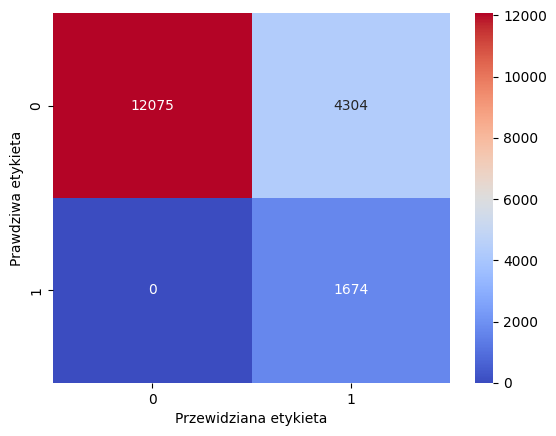

              precision    recall  f1-score   support

       False       1.00      0.74      0.85     16379
        True       0.28      1.00      0.44      1674

    accuracy                           0.76     18053
   macro avg       0.64      0.87      0.64     18053
weighted avg       0.93      0.76      0.81     18053



In [48]:
best_tree = grid_search.best_estimator_
y_pred = best_tree.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

print(classification_report(y_test, y_pred))

# Wnioski 

Najlepsze parametry: {'ccp_alpha': 0.01, 'class_weight': {0: 1, 1: 25}, 'max_depth': None}

Model poradził sobie ze 100% kwalifikacją wszystkich zagrożeń poprawnie, lecz widać, że ma problem z błędną klasyfikacją wyników negatywnych, 25% wyników negatywnych została sklasyfikowana jako zagrożenie, co bardzo obciąża finansowo agencje kosmiczne 